In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df=pd.read_csv("Downloads/Churn_Modelling.csv")


In [18]:
df.head()
     

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)


In [23]:
df.shape

(10000, 11)

In [25]:
df.dtypes


CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [27]:
## EDA

In [29]:
df.describe()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [31]:
df.isnull().sum()


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [33]:
##checking the distribution of the target variable

In [35]:
df["Exited"].value_counts()


Exited
0    7963
1    2037
Name: count, dtype: int64

In [37]:
#1.Age distribution

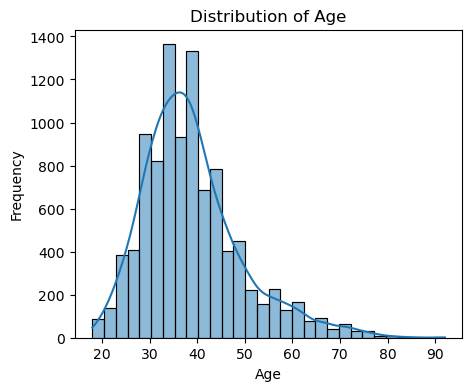

In [39]:
plt.figure(figsize=(5,4))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [40]:
##2. Balance Distribution

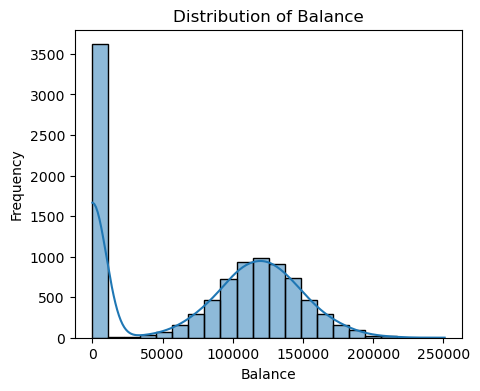

In [43]:
plt.figure(figsize=(5,4))

sns.histplot(df["Balance"], kde=True)

plt.title("Distribution of Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()


In [44]:
#3.Credit score distribution

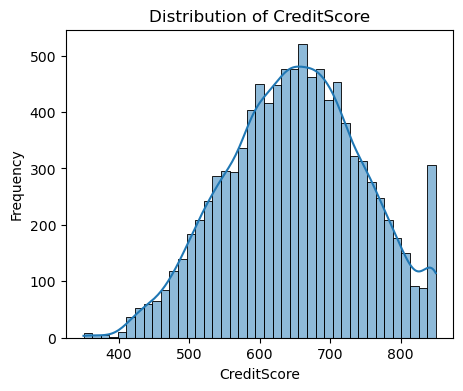

In [47]:
plt.figure(figsize=(5,4))

sns.histplot(df["CreditScore"], kde=True)

plt.title("Distribution of CreditScore")
plt.xlabel("CreditScore")
plt.ylabel("Frequency")

plt.show()

In [49]:
#Analysis of categorical feature
#1.Geography distribution

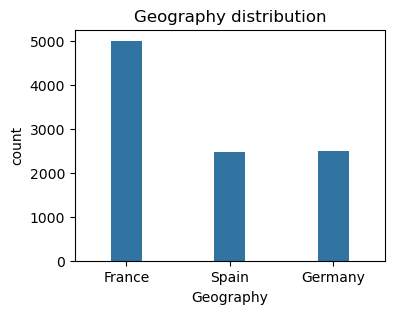

In [51]:
plt.figure(figsize=(4,3))
sns.countplot(x='Geography', data=df, width=0.3)

plt.title("Geography distribution")
plt.xlabel("Geography")
plt.ylabel("count")

plt.show()

In [53]:
#2. Gender Distribution

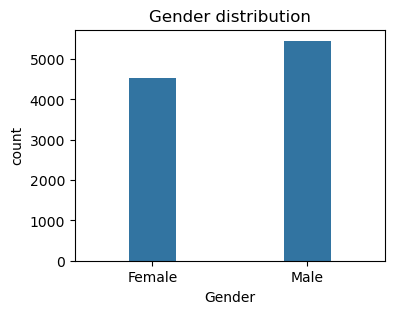

In [55]:
plt.figure(figsize=(4,3))
sns.countplot(x='Gender', data=df, width=0.3)

plt.title("Gender distribution")
plt.xlabel("Gender")
plt.ylabel("count")

plt.show()

In [57]:
## Bivariate Analysis

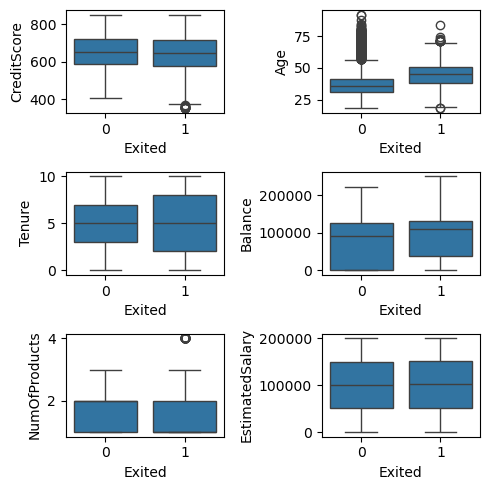

In [59]:
fig, axarr =plt.subplots(3,2, figsize=(5,5))

sns.boxplot(x='Exited', y= 'CreditScore', data=df , ax=axarr[0][0])
sns.boxplot(x='Exited', y= 'Age', data=df , ax=axarr[0][1])

sns.boxplot(x='Exited', y= 'Tenure', data=df , ax=axarr[1][0])
sns.boxplot(x='Exited', y= 'Balance', data=df , ax=axarr[1][1])

sns.boxplot(x='Exited', y= 'NumOfProducts', data=df , ax=axarr[2][0])
sns.boxplot(x='Exited', y= 'EstimatedSalary', data=df , ax=axarr[2][1])

plt.tight_layout()
plt.show()


In [60]:
#Correlation analysis

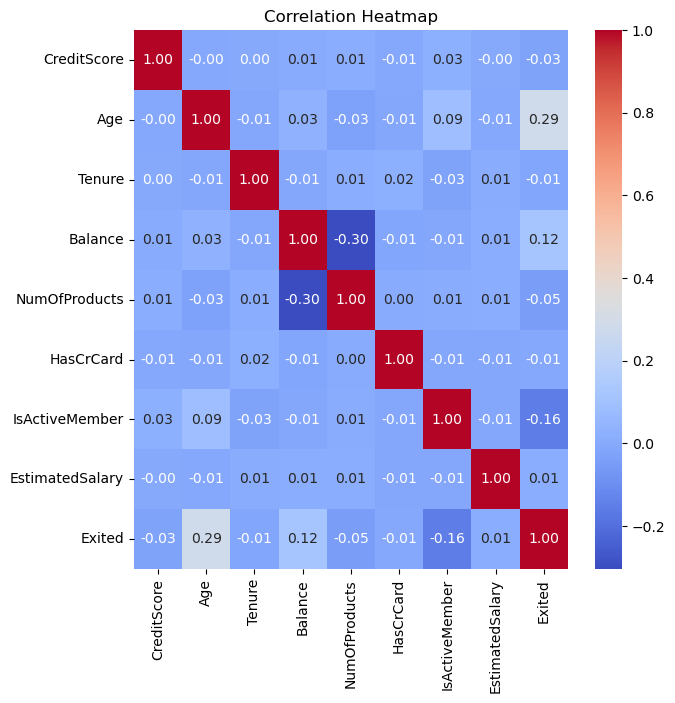

In [63]:
plt.figure(figsize=(7,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

In [64]:
# Feature Engineering

In [65]:
#1. Balance to salary ratio

In [69]:
df["balance_to_salary"]=df["Balance"]/df["EstimatedSalary"]


In [71]:
#2.Tenure by age

In [73]:
df["tenure_by_age"]=df["Tenure"]/df["Age"]


In [75]:
df.shape

(10000, 13)

In [77]:
##Feature Encoding

In [79]:
##1.Label encoding - Gender

In [81]:
from sklearn.preprocessing import LabelEncoder


In [83]:
le=LabelEncoder()


In [85]:
df["Gender"]=le.fit_transform(df["Gender"])


In [87]:
#2.One GHot encoding - Geography

In [89]:
df=pd.get_dummies(df, columns=["Geography"], drop_first=True)


In [91]:
df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_salary,tenure_by_age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512,False,True


In [93]:
#**Defining Features anf the Target Variable **

In [95]:

X= df.drop("Exited", axis=1)
y=df["Exited"]
     


In [97]:
from sklearn.model_selection import train_test_split


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [101]:
X_train.shape


(8000, 13)

In [103]:
y_test.shape


(2000,)

In [105]:
#Feature Scaling

In [107]:
from sklearn.preprocessing import StandardScaler


In [109]:
sc=StandardScaler()


In [111]:

X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [113]:
##Model Training

##1.Logistic Regression

##2.KNN Classifier

##3.Naive Bayes

##4.Random Forest

##5.XGB Classifier

##6.ANN - Artificial Neural Network

In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [117]:
##Logistic Regression

In [119]:
from sklearn.linear_model import LogisticRegression


In [121]:
lr_model=LogisticRegression()


In [123]:
lr_model.fit(X_train, y_train)


LogisticRegression()

In [125]:
LogisticRegression()


LogisticRegression()

In [127]:
y_pred_lr = lr_model.predict(X_test)


In [129]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [131]:
from sklearn.metrics import confusion_matrix


Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

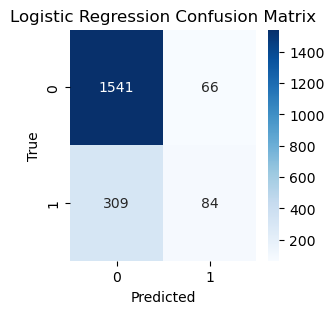

In [133]:

cm=confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")

In [135]:
cm


array([[1541,   66],
       [ 309,   84]], dtype=int64)

In [137]:

model_results=[]

model_results.append({"Model":"Logistic Regression",
                       "Accuracy":lr_accuracy,
                       "Precision":lr_precision,
                       "Recall":lr_recall,
                       "F1 Score":lr_f1})

In [139]:
#2.KNN - Classifier

In [141]:
from sklearn.neighbors import KNeighborsClassifier


In [143]:
knn_model= KNeighborsClassifier()


In [145]:
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

In [147]:
y_predict_knn= knn_model.predict(X_test)


In [149]:
knn_accuracy = accuracy_score(y_test, y_predict_knn)
knn_precision = precision_score(y_test, y_predict_knn)
knn_recall = recall_score(y_test, y_predict_knn)
knn_f1 = f1_score(y_test, y_predict_knn)

In [151]:
print("Accuracy: ", knn_accuracy)
print("Precision: ", knn_precision)
print("recall: ", knn_recall)
print("f1 Score: ", knn_f1)

Accuracy:  0.831
Precision:  0.6170212765957447
recall:  0.36895674300254455
f1 Score:  0.46178343949044587


In [153]:
cm=confusion_matrix(y_test, y_predict_knn)


Text(0.5, 1.0, 'KNN Classifier Confusion Matrix')

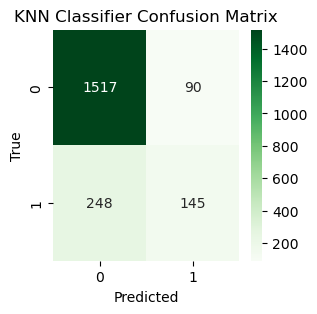

In [155]:
plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KNN Classifier Confusion Matrix")

In [157]:
model_results.append({"Model":"KNN Classifier",
                       "Accuracy":knn_accuracy,
                       "Precision":knn_precision,
                       "Recall":knn_recall,
                       "F1 Score":knn_f1})

In [159]:
##Naive Bayes

In [161]:
from sklearn.naive_bayes import GaussianNB


In [163]:
nb_model=GaussianNB()


In [165]:
nb_model.fit(X_train, y_train)


GaussianNB()

In [167]:
y_predict_nb= nb_model.predict(X_test)


In [169]:
nb_accuracy=accuracy_score(y_test, y_predict_nb)
nb_precision= precision_score(y_test, y_predict_nb)
nb_recall = recall_score(y_test, y_predict_nb)
nb_f1 = f1_score(y_test, y_predict_nb)

print("accuracy:",nb_accuracy)
print("precision:",nb_precision)
print("recall:",nb_recall)
print("F1 score:",nb_f1)

accuracy: 0.8275
precision: 0.6967213114754098
recall: 0.21628498727735368
F1 score: 0.3300970873786408


In [171]:
cm_nb= confusion_matrix(y_test, y_predict_nb)


In [173]:
cm_nb


array([[1570,   37],
       [ 308,   85]], dtype=int64)

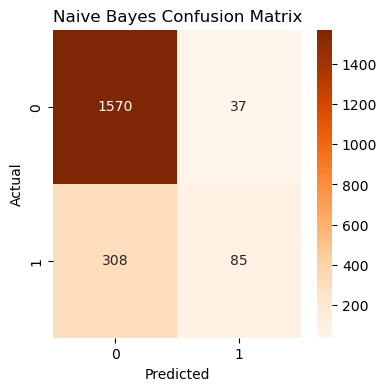

In [175]:
plt.figure(figsize=(4,4))

sns.heatmap(cm_nb, annot=True, cmap='Oranges', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [177]:
model_results.append({"Model":"Naive Bayes",
                       "Accuracy":nb_accuracy,
                       "Precision":nb_precision,
                       "Recall":nb_recall,
                       "F1 Score":nb_f1})

In [179]:
##Random Forest

In [181]:
from sklearn.ensemble import RandomForestClassifier


In [183]:
rf_model=RandomForestClassifier()


In [185]:
rf_model.fit(X_train, y_train)


RandomForestClassifier()

In [186]:
y_predict_rf= rf_model.predict(X_test)


In [187]:
rf_accuracy=accuracy_score(y_test, y_predict_rf)
rf_precision= precision_score(y_test, y_predict_rf)
rf_recall = recall_score(y_test, y_predict_rf)
rf_f1 = f1_score(y_test, y_predict_rf)

print("accuracy:",rf_accuracy)
print("precision:",rf_precision)
print("recall:",rf_recall)
print("F1 score:",rf_f1)


accuracy: 0.8685
precision: 0.773109243697479
recall: 0.4681933842239186
F1 score: 0.5832012678288431


In [191]:
model_results.append({"Model":"Random Forest",
                       "Accuracy":rf_accuracy,
                       "Precision":rf_precision,
                       "Recall":rf_recall,
                       "F1 Score":rf_f1})
     

In [193]:
from xgboost import XGBClassifier
model_xgb= XGBClassifier()

In [195]:
model_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [196]:
y_predict_xgb= model_xgb.predict(X_test)


In [199]:
xgb_accuracy=accuracy_score(y_test, y_predict_xgb)
xgb_precision= precision_score(y_test, y_predict_xgb)
xgb_recall = recall_score(y_test, y_predict_xgb)
xgb_f1 = f1_score(y_test, y_predict_xgb)

print("accuracy:",xgb_accuracy)
print("precision:",xgb_precision)
print("recall:",xgb_recall)
print("F1 score:",xgb_f1)

accuracy: 0.8535
precision: 0.6798561151079137
recall: 0.48091603053435117
F1 score: 0.563338301043219


In [213]:
## ANN Artificial Neural Network

In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [18]:
!pip install --upgrade --force-reinstall tensorflow numpy

^C
Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
  

In [201]:
!pip install "numpy<2.0.0" --force-reinstall


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [203]:
import tensorflow as tf
from tensorflow import keras

In [205]:
import numpy as np


In [207]:
model= keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(12, activation='relu'),
    keras.layers.Dense(6, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [209]:
#Complie the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [211]:
history=model.fit(X_train, y_train,
                  epochs=100,
                  batch_size=32,
                  validation_split=0.2
                  )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7589 - loss: 0.5435 - val_accuracy: 0.7931 - val_loss: 0.4748
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7931 - loss: 0.4542 - val_accuracy: 0.7956 - val_loss: 0.4411
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7966 - loss: 0.4329 - val_accuracy: 0.8100 - val_loss: 0.4268
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8081 - loss: 0.4205 - val_accuracy: 0.8175 - val_loss: 0.4176
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8164 - loss: 0.4095 - val_accuracy: 0.8213 - val_loss: 0.4088
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8220 - loss: 0.3993 - val_accuracy: 0.8269 - val_loss: 0.4012
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8264 - loss: 0.3913 - val_accuracy: 0.8275 - val_loss: 0.3951
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8261 - loss: 0.3853 - val_accu

In [223]:
y_pred_ann = (y_pred_ann >= 0.5).astype(int)


In [225]:
ann_accuracy=accuracy_score(y_test, y_pred_ann)
ann_precision= precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)

print("accuracy:",ann_accuracy)
print("precision:",ann_precision)
print("recall:",ann_recall)
print("F1 score:",ann_f1)

accuracy: 0.856
precision: 0.7108433734939759
recall: 0.45038167938931295
F1 score: 0.5514018691588785


In [229]:
model_results.append({"Model":"ANN Model",
                       "Accuracy":ann_accuracy,
                       "Precision":ann_precision,
                       "Recall":ann_recall,
                       "F1 Score":ann_f1})

In [231]:
result_df= pd.DataFrame(model_results)


In [233]:
result_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8125,0.560000,0.213740,0.309392
1,KNN Classifier,0.8310,0.617021,0.368957,0.461783
2,Naive Bayes,0.8275,0.696721,0.216285,0.330097
3,Random Forest,0.8685,0.773109,0.468193,0.583201
4,ANN Model,0.8560,0.710843,0.450382,0.551402
5,ANN Model,0.8560,0.710843,0.450382,0.551402
